# Wind Statistics Plots

In [1]:
import pandas as pd 
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import PurePath
from datetime import datetime, time
from windrose import WindroseAxes

from methods_release_cleaning_data import load_clean_release_data

In [2]:
def plot_wind_stats(week):
    clean_data = load_clean_release_data(week)

    # Calculate windspeed and wind direction coefficient of variation
    clean_data['Windspeed20m_CV'] = clean_data['Windspeed20m_Std'] / clean_data['Windspeed20m_Avg']
    clean_data['WindDir20m_CV'] = clean_data['WindDir20m_Std'] / 360  # CV for circular data
    
    # Create 2x2 subplots
    fig, ax = plt.subplots(2, 2, figsize=(18, 12))  # Create 2x2 subplots

    # Plot windspeed average and variability
    ax[0, 0].errorbar(
        clean_data['ReleaseID'],  # X-axis: Release IDs
        clean_data['Windspeed20m_Avg'],  # Y-axis: Average windspeed
        yerr=clean_data['Windspeed20m_Std'],  # Error bars: Std dev of windspeed
        fmt='o',  # Marker type
        ecolor='gray',  # Error bar color
        capsize=3,  # Size of error bar caps
        label='Windspeed (20m)'
    )
    ax[0, 0].set_xlabel('Release ID')
    ax[0, 0].set_ylabel('Windspeed (20m) [m/s]')
    ax[0, 0].set_title('Windspeed Averages and Variability')
    ax[0, 0].legend()
    ax[0, 0].grid(True)

    # Plot windspeed coefficient of variation
    ax[0, 1].scatter(
        clean_data['ReleaseID'],  # X-axis: Release IDs
        clean_data['Windspeed20m_CV'],  # Y-axis: Coefficient of variation
        color='blue',
        label='Windspeed CV'
    )
    ax[0, 1].set_xlabel('Release ID')
    ax[0, 1].set_ylabel('Coefficient of Variation')
    ax[0, 1].set_title('Windspeed Coefficient of Variation')
    ax[0, 1].legend()
    ax[0, 1].grid(True)

    # Plot wind direction average and variability
    ax[1, 0].errorbar(
        clean_data['ReleaseID'],  # X-axis: Release IDs
        clean_data['WindDir20m_Avg'],  # Y-axis: Average wind direction
        yerr=clean_data['WindDir20m_Std'],  # Error bars: Std dev of wind direction
        fmt='o',  # Marker type
        color='red',
        ecolor='gray',  # Error bar color
        capsize=3,  # Size of error bar caps
        label='Wind Direction (20m)'
    )
    ax[1, 0].set_xlabel('Release ID')
    ax[1, 0].set_ylabel('Wind Direction [deg]')
    ax[1, 0].set_title('Wind Direction Averages and Variability')
    ax[1, 0].legend()
    ax[1, 0].grid(True)

    # Plot wind direction coefficient of variation
    ax[1, 1].scatter(
        clean_data['ReleaseID'],  # X-axis: Release IDs
        clean_data['WindDir20m_CV'],  # Y-axis: Coefficient of variation
        color='purple',
        label='Wind Direction CV'
    )
    ax[1, 1].set_xlabel('Release ID')
    ax[1, 1].set_ylabel('Coefficient of Variation')
    ax[1, 1].set_title('Wind Direction Coefficient of Variation')
    ax[1, 1].legend()
    ax[1, 1].grid(True)

    # Set overall title and adjust layout
    fig.suptitle(f'Week {week} Wind Characteristics', fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the suptitle

    # Save the plot
    plt.savefig(f'../plots/wind/W{week}_wind_characterization_2x2.png')
    plt.show()


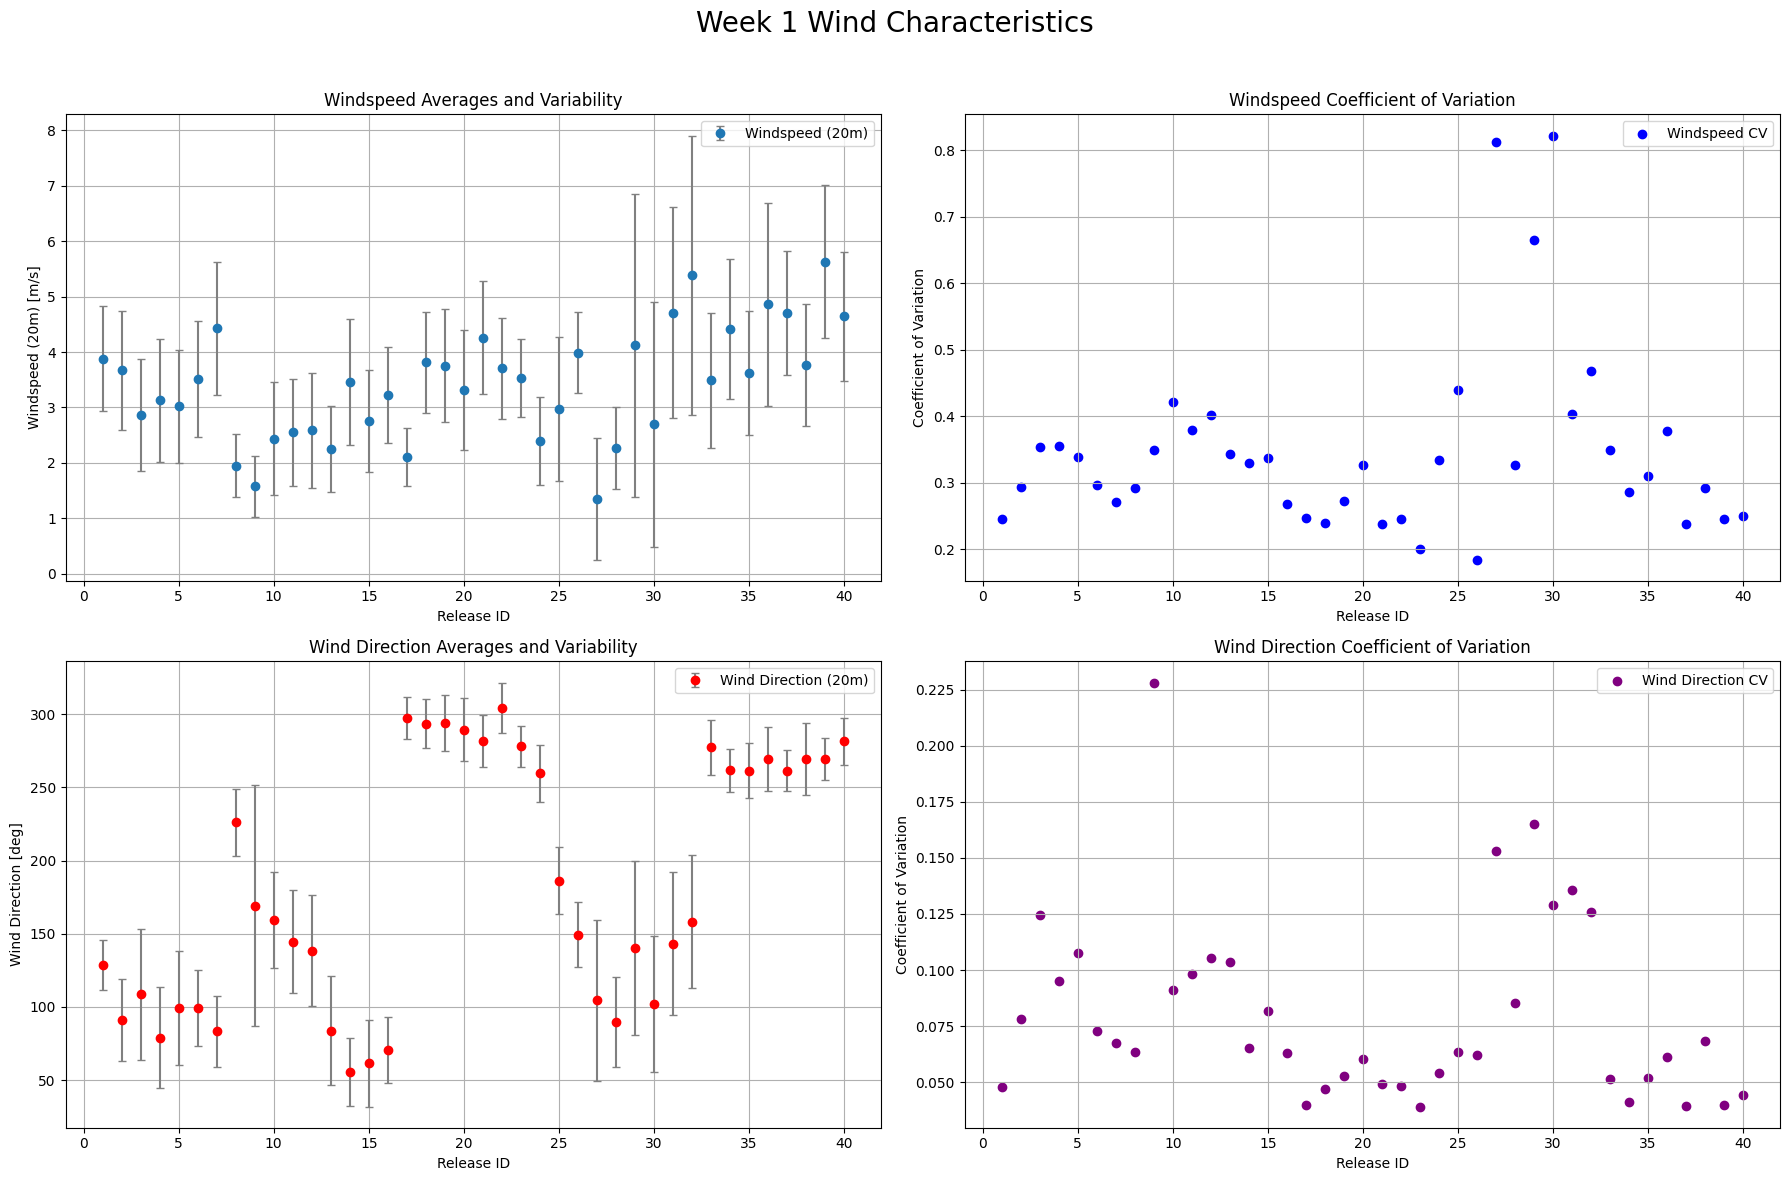

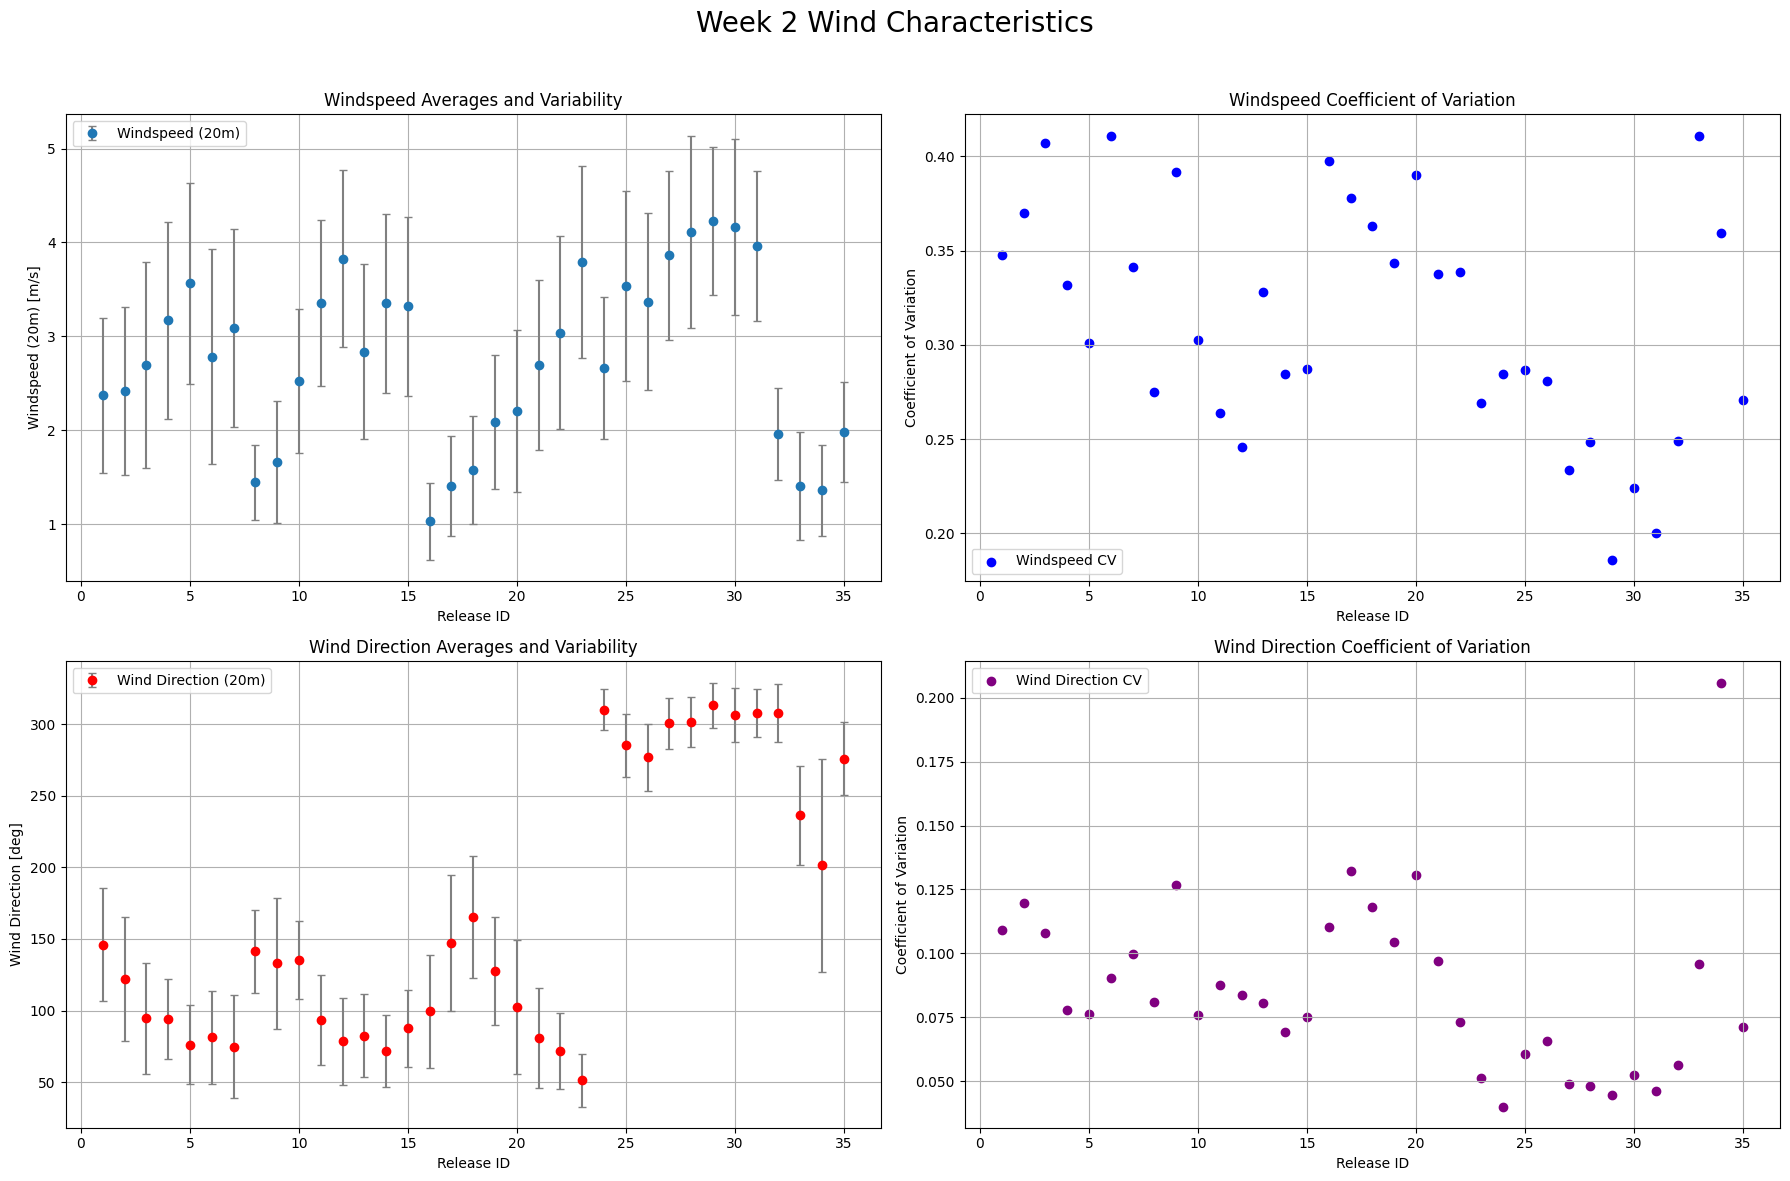

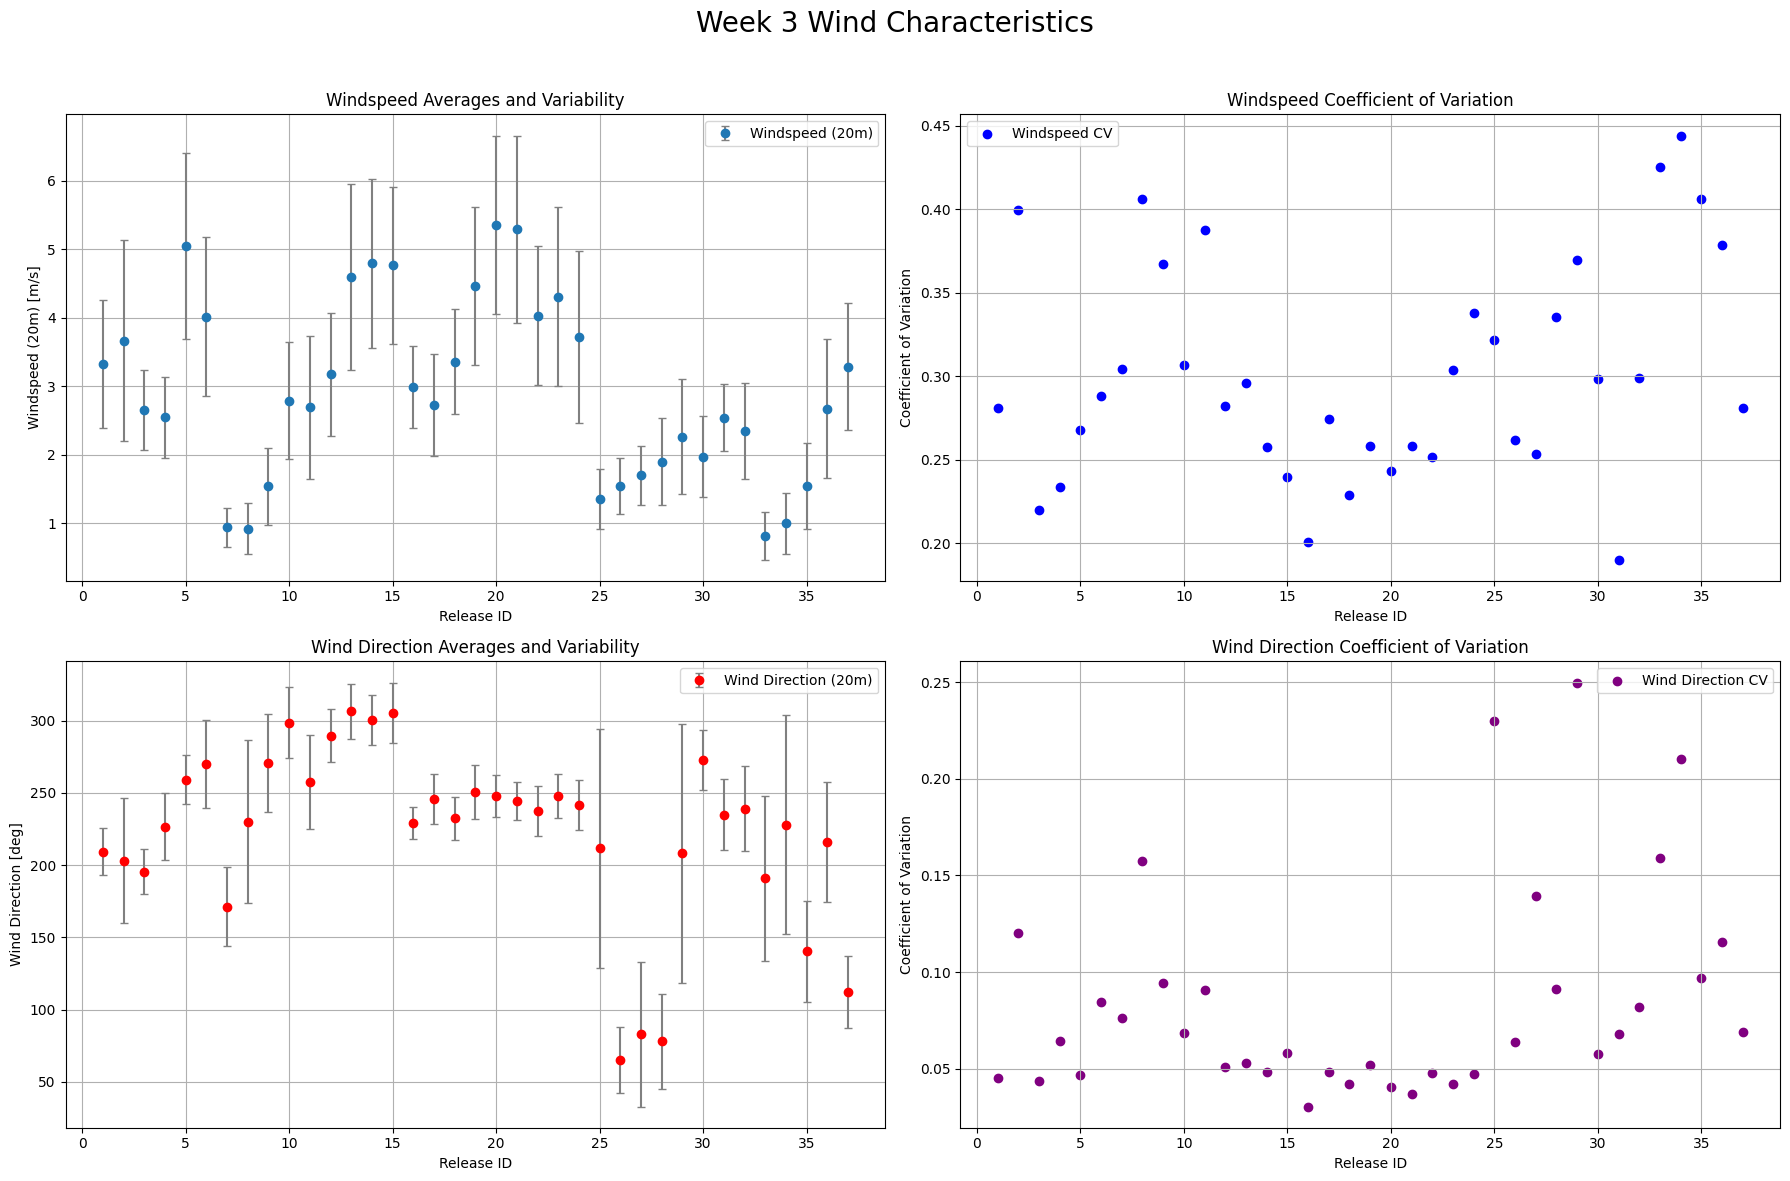

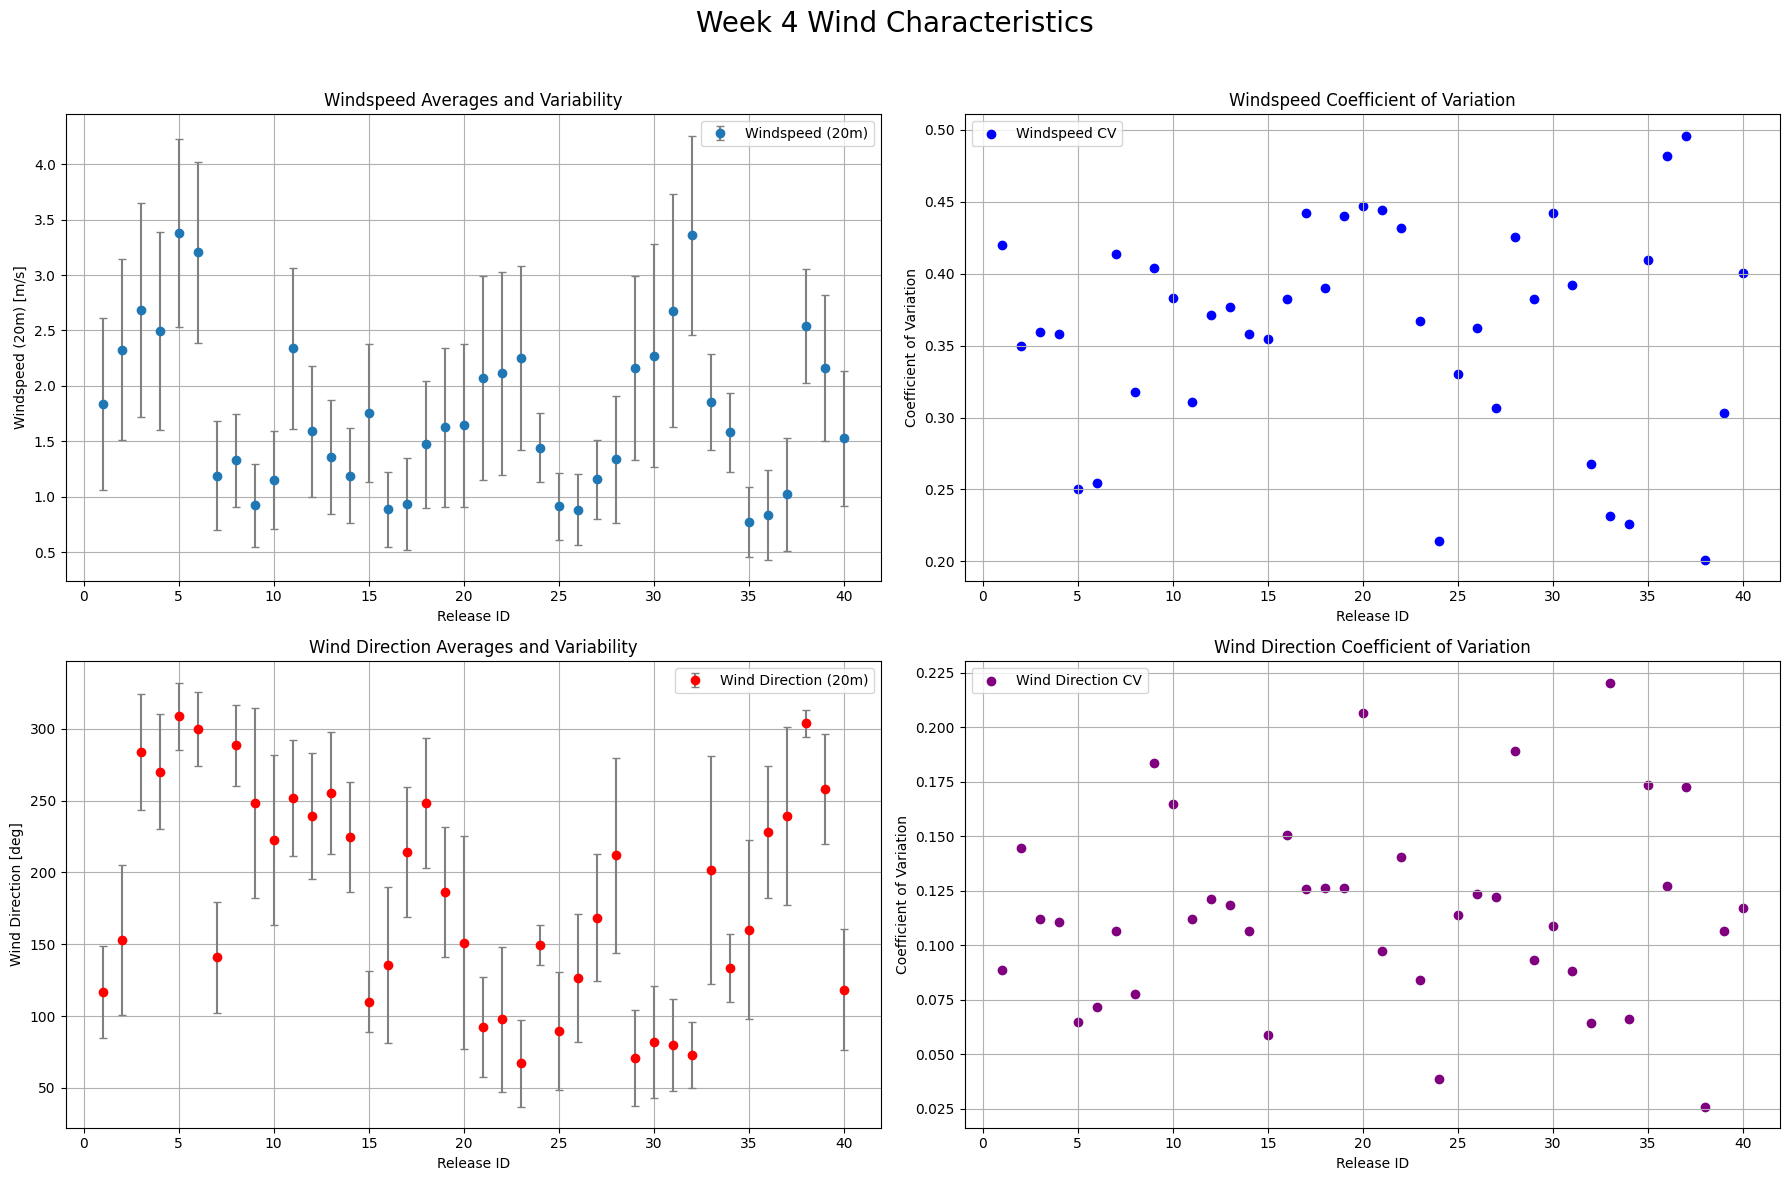

In [3]:
# plot wind data
for week in [1, 2, 3, 4]:
    plot_wind_stats(week)